# **Section 1 - Dataset Import From SQL & Overview**

In [77]:
import pandas as pd

df = pd.read_csv("amazon_cleaned.csv")
df.tail(5)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
107155,91839,408-0472466-5739504,29-06-2022,Shipped,Amazon,Amazon.in,Expedited,SET329,SET329-KR-NP-XXL,Set,...,1,INR,666,NAGAON,ASSAM,782138.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
107156,91840,408-7402152-7886728,29-06-2022,Shipped,Amazon,Amazon.in,Expedited,J0225,J0225-SKD-S,Set,...,1,INR,1284,GURUGRAM,HARYANA,122003.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
107157,91841,408-7402152-7886728,29-06-2022,Shipped,Amazon,Amazon.in,Expedited,J0225,J0225-SKD-XXL,Set,...,1,INR,1284,GURUGRAM,HARYANA,122003.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN
107158,91842,404-9159539-4205957,29-06-2022,Shipped,Amazon,Amazon.in,Expedited,MEN5004,MEN5004-KR-XL,kurta,...,1,INR,709,AHMEDABAD,Gujarat,380058.0,IN,NaN,False,NaN
107159,91843,408-6909744-3456308,29-06-2022,Shipped,Amazon,Amazon.in,Expedited,J0332,J0332-DR-XXL,Western Dress,...,1,INR,668,Hyderabad,TELANGANA,500090.0,IN,NaN,False,NaN


**Step 1 — Basic Structure Validation in Python**

In [78]:
df.shape

(107160, 23)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107160 entries, 0 to 107159
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               107160 non-null  int64  
 1   Order ID            107160 non-null  object 
 2   Date                107160 non-null  object 
 3   Status              107160 non-null  object 
 4   Fulfilment          107160 non-null  object 
 5   Sales Channel       107160 non-null  object 
 6   ship-service-level  107160 non-null  object 
 7   Style               107160 non-null  object 
 8   SKU                 107160 non-null  object 
 9   Category            107160 non-null  object 
 10  Size                107160 non-null  object 
 11  ASIN                107160 non-null  object 
 12  Courier Status      107160 non-null  object 
 13  Qty                 107160 non-null  int64  
 14  currency            107160 non-null  object 
 15  Amount              107160 non-nul

In [80]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,107160.000000,107160.000000,107160.000000,107134.000000
mean,64259.268346,1.003817,663.036441,463244.542414
std,37270.067855,0.073788,269.430351,191040.621943
min,1.000000,1.000000,199.000000,110001.000000
25%,32107.750000,1.000000,459.000000,382421.000000
50%,63844.500000,1.000000,625.000000,500032.000000
75%,96848.750000,1.000000,788.000000,600017.000000
max,128974.000000,8.000000,5584.000000,855117.000000


# **SECTION 2 - Feature Engineering**

**Step 1 - Create Month Column Properly**

In [81]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["YearMonth"] = df["Date"].dt.to_period("M")

**Step 2 - Create Revenue Per Unit**

In [82]:
df["price_per_unit"] = df["Amount"] / df["Qty"]

**Step 3 - Check Price Distribution**

In [83]:
df["price_per_unit"].describe()

,price_per_unit
count,107160.000000
mean,660.765594
std,265.158841
min,199.000000
25%,459.000000
50%,618.000000
75%,788.000000
max,2598.000000


# **SECTION 3 - Correlation Analysis**

**1. Correlation Between Quantity and Amount**

In [84]:
df[["Qty", "Amount"]].corr()

,Qty,Amount
Qty,1.000000,0.151826
Amount,0.151826,1.000000


**2. Correlation Between Price and Quantity**

In [85]:
df[["price_per_unit", "Qty"]].corr()

,price_per_unit,Qty
price_per_unit,1.000000,-0.012835
Qty,-0.012835,1.000000


# **SECTION 4 - Advanced Visualization**

**1. Monthly Revenue Line Chart**

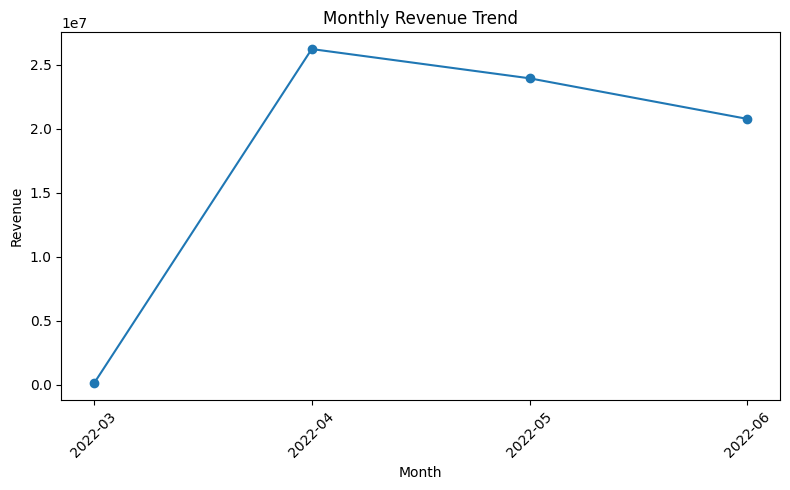

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date column is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create proper month column
df["YearMonth"] = df["Date"].dt.to_period("M")

# Aggregate monthly revenue
monthly_rev = (
    df.groupby("YearMonth")["Amount"]
    .sum()
    .reset_index()
)

# Convert Period to string for clean plotting
monthly_rev["YearMonth"] = monthly_rev["YearMonth"].astype(str)

# Plot properly
plt.figure(figsize=(8,5))
plt.plot(monthly_rev["YearMonth"], monthly_rev["Amount"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**2. Category Revenue Distribution**

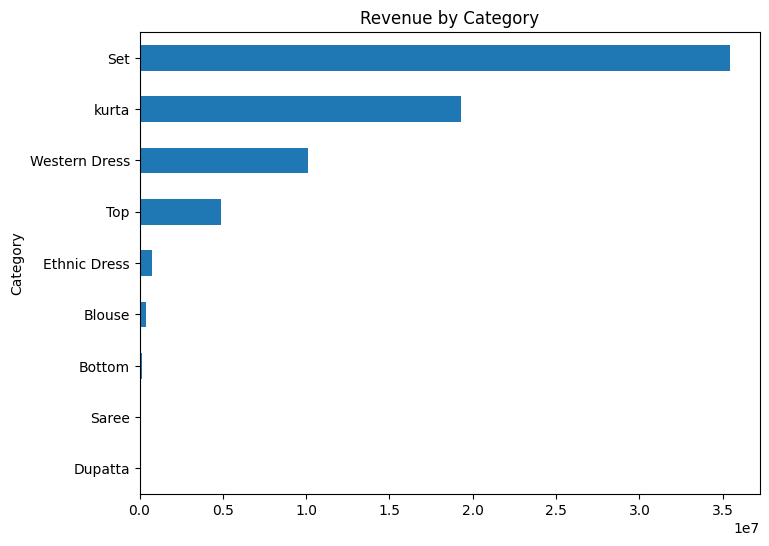

In [87]:
category_rev = df.groupby("Category")["Amount"].sum().sort_values()

category_rev.plot(kind="barh", figsize=(8,6))
plt.title("Revenue by Category")
plt.show()

# **Section 5 - Revenue Decompositon**

**Step 1 — Calculate Monthly Quantity**

In [88]:
monthly_qty = df.groupby("YearMonth")["Qty"].sum()
monthly_qty

,Qty
YearMonth,
2022-03,152
2022-04,41168
2022-05,35473
2022-06,30776


**Step 2 — Monthly Average Price per Unit**

In [89]:
monthly_price = df.groupby("YearMonth")["price_per_unit"].mean()

monthly_price

,price_per_unit
YearMonth,
2022-03,623.750000
2022-04,637.504499
2022-05,675.238207
2022-06,675.375554


Revenue decline from April to June was driven primarily by decreasing sales volume despite an increase in average selling price, indicating weakening demand rather than pricing inefficiency.

**Step 3 — Calculate Monthly Quantity by Category**

In [90]:
monthly_cat_qty = df.groupby(["YearMonth", "Category"])["Qty"].sum()

monthly_cat_qty

YearMonth  Category     
2022-03    Blouse               1
           Set                 65
           Top                  9
           Western Dress        6
           kurta               71
2022-04    Blouse             355
           Bottom             158
           Ethnic Dress       296
           Saree               65
           Set              16847
           Top               3414
           Western Dress     3582
           kurta            16451
2022-05    Blouse             275
           Bottom             118
           Ethnic Dress       384
           Saree               51
           Set              13377
           Top               3505
           Western Dress     5127
           kurta            12636
2022-06    Blouse             155
           Bottom              93
           Dupatta              3
           Ethnic Dress       297
           Saree               30
           Set              11324
           Top               2190
           Western Dress     4299
           kurta            12385
Name: Qty, dtype: int64

**Step 4 — Calculate Average Units Per Order per Month.**

In [91]:
monthly_orders = df.groupby("YearMonth")["Order ID"].nunique()
monthly_units = df.groupby("YearMonth")["Qty"].sum()

avg_units_per_order = monthly_units / monthly_orders
avg_units_per_order

,0
YearMonth,
2022-03,1.085714
2022-04,1.076400
2022-05,1.076832
2022-06,1.076875


**Step 5 — Calculate Monthly Order Count**

In [92]:
monthly_orders = df.groupby("YearMonth")["Order ID"].nunique()
monthly_orders

,Order ID
YearMonth,
2022-03,140
2022-04,38246
2022-05,32942
2022-06,28579


# **Section 6 - BUSINESS INSIGHTS**

## 1. Revenue Structure Is Highly Concentrated

Nearly 76% of total revenue is generated from just two categories: Set and Kurta.  
This indicates strong product-market fit in these categories but also heavy business dependency on limited product lines.  
Such reliance creates structural concentration risk — if demand shifts away from these categories, overall revenue will decline sharply.

---

## 2. Revenue Decline Was Volume-Driven

From April to June, order count declined consistently while units per order remained stable (~1.07) and average price per unit slightly increased.  
Therefore, the revenue decline was caused by decreasing order volume, not pricing inefficiency.  
This suggests weakening demand or reduced customer traffic rather than pricing problems.

---

## 3. Basket Size Is Stable

Customers consistently purchase about one item per order.  
This reflects limited cross-selling and single-product purchase behavior.  
The business is transaction-driven rather than bundle-driven, highlighting an opportunity to encourage multi-item purchases.

---

## 4. Weak Price Sensitivity

Correlation analysis shows a very weak relationship between price and quantity.  
This suggests customers are not highly price-sensitive, and purchase decisions are category-driven rather than discount-driven.  
Heavy discounting may therefore not significantly increase volume.

---

## 5. Revenue Is Traffic Dependent

Since revenue is determined by the formula:  
**Revenue = Orders × Units × Price**  

And only orders are declining, business performance is primarily traffic-driven.  
This means customer acquisition and retention are more critical levers than pricing adjustments.


# **Section 7 - STRATEGIC RECOMMENDATIONS**

## 1. Focus on Order Growth, Not Price Cuts

Since price sensitivity is weak, aggressive discounting may not significantly boost demand.  
Instead, the focus should be on driving order growth through stronger marketing campaigns, improved platform visibility, and enhanced customer acquisition strategies.  
By investing in these areas, the business can expand its reach and attract new customers without eroding margins through unnecessary price cuts.

---

## 2. Reduce Category Concentration Risk

Currently, revenue dependence on Set and Kurta is high, which creates category concentration risk.  
To mitigate this, mid-tier categories such as Western Dresses and Tops should be promoted more actively.  
Diversifying the product portfolio and running category-specific campaigns can help balance revenue streams and reduce reliance on a limited set of products.

---

## 3. Improve Cross-Selling Strategy

Another opportunity lies in improving cross-selling strategies.  
With the average units per order hovering near one, there is room to increase basket size.  
Bundling complementary items, offering “Buy 2 Save More” deals, and recommending related products can encourage customers to purchase more per transaction.  
This approach boosts revenue without requiring additional traffic.

---

## 4. Monitor Monthly Order Trend Closely

Since order count is the primary driver of revenue, monitoring monthly order trends closely is essential.  
Building an early warning system that flags when order growth drops below a set threshold allows for timely intervention.  
A quick marketing push in response to declining growth can help stabilize performance and maintain momentum.
